In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

# Load data
df = pd.read_csv("../data/german_credit_data.csv")

# Clean
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

# Create target (same as Day 2 and 3 — must match)
df["target"] = (df["Credit amount"] > 2000).astype(int)

# Save Sex column before encoding
sex_col = df["Sex"].copy()

print(df.shape)
print(df.columns.tolist())

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1000, 12)
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk', 'Age_group', 'target']


In [2]:
from sklearn.model_selection import train_test_split

y = df["target"]
X = df.drop("target", axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Align Sex column
sex_test = sex_col.loc[X_test.index]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 22)
X_test shape: (200, 22)


In [3]:
model = joblib.load("../models/fair_model.pkl")
print("Model loaded successfully")

Model loaded successfully


In [4]:
# Create SHAP explainer
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)

print("SHAP values computed!")
print("Shape:", shap_values.values.shape)

SHAP values computed!
Shape: (200, 22)


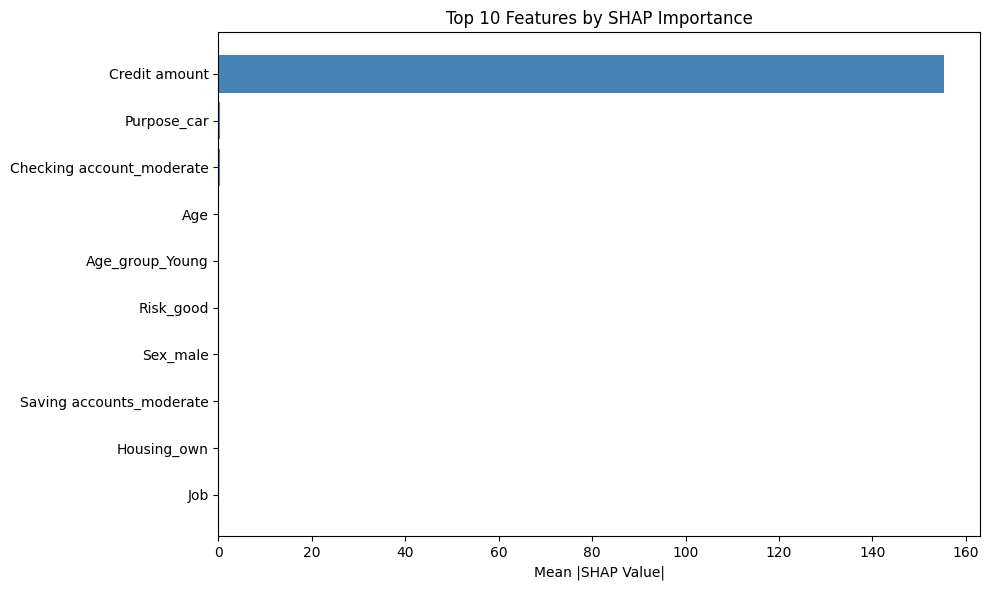

Saved.


In [10]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Get mean absolute SHAP values
shap_vals = shap_values.values  # extract numpy array
mean_shap = np.abs(shap_vals).mean(axis=0)

# Get feature names
feature_names = X_test.columns.tolist()

# Sort top 10
indices = np.argsort(mean_shap)[-10:]
top_features = [feature_names[i] for i in indices]
top_values = mean_shap[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features, top_values, color="steelblue")
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 10 Features by SHAP Importance")
plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/shap_importance.png", dpi=150)
plt.show()
print("Saved.")

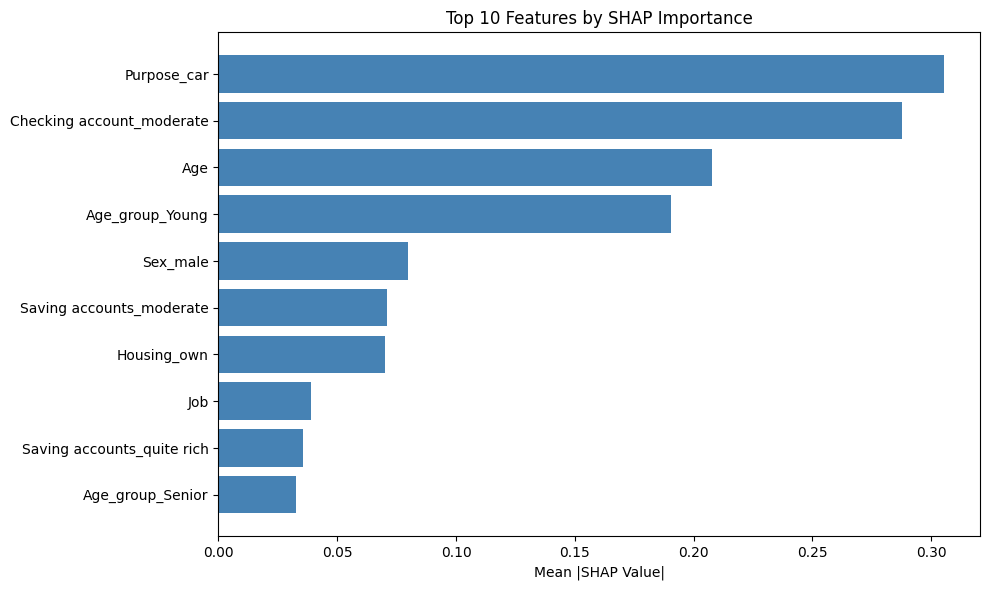

Saved.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

shap_vals = shap_values.values
feature_names = X_test.columns.tolist()

# Remove Risk_good (target leakage) and Credit amount outlier
exclude = ["Risk_good", "Credit amount"]
keep_idx = [i for i, f in enumerate(feature_names) if f not in exclude]

filtered_vals = shap_vals[:, keep_idx]
filtered_names = [feature_names[i] for i in keep_idx]

# Mean absolute SHAP
mean_shap = np.abs(filtered_vals).mean(axis=0)

# Top 10
indices = np.argsort(mean_shap)[-10:]
top_features = [filtered_names[i] for i in indices]
top_values = mean_shap[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features, top_values, color="steelblue")
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 10 Features by SHAP Importance")
plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/shap_importance.png", dpi=150)
plt.show()
print("Saved.")

<Figure size 640x480 with 0 Axes>

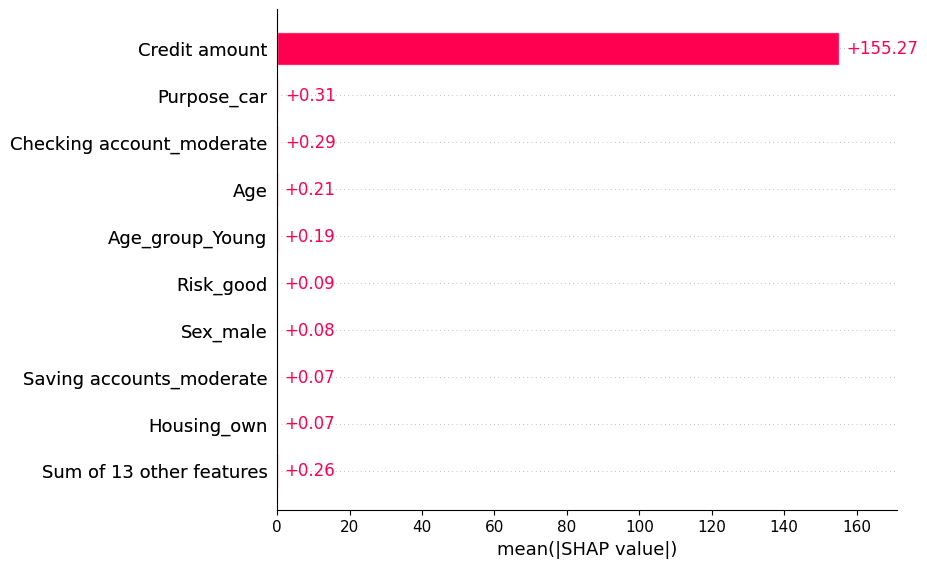

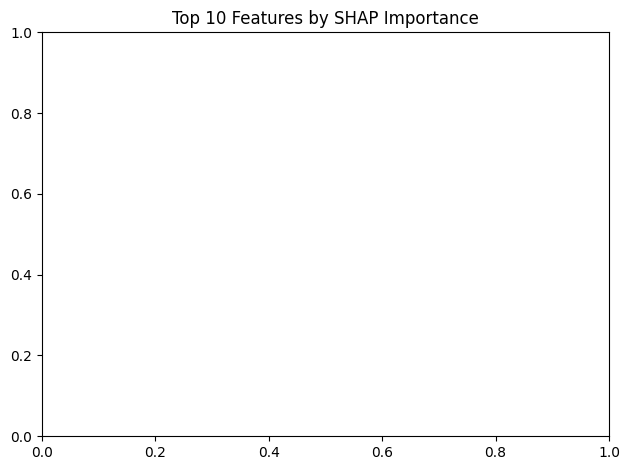

In [14]:
import os
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/shap_importance.png")
plt.show()
shap.plots.bar(shap_values, max_display=10)
plt.title("Top 10 Features by SHAP Importance")
plt.tight_layout()

plt.savefig("outputs/shap_importance.png")
plt.show()

In [9]:
print("Type of shap_values:", type(shap_values))
print("Shape of shap_values:", shap_values.shape if hasattr(shap_values, 'shape') else "no shape")
print("X_test shape:", X_test.shape)

Type of shap_values: <class 'shap._explanation.Explanation'>
Shape of shap_values: (200, 22)
X_test shape: (200, 22)


In [12]:
import numpy as np

shap_vals = shap_values.values
print("shap_vals shape:", shap_vals.shape)
print("shap_vals sample:\n", shap_vals[:3])
print("mean_shap:", np.abs(shap_vals).mean(axis=0))
print("feature names:", X_test.columns.tolist())

shap_vals shape: (200, 22)
shap_vals sample:
 [[-0.24828707973151362 0.004625578516682905 -27.10348757560866
  0.012129635681898156 -0.11328139843372652 0.0475477864171631
  -0.013025671861492578 0.03631257152477698 0.01697953721528707
  -0.005850284581963327 -0.21968790249101083 0.007078735302144214
  -0.254649118912718 0.0010241385727690988 -0.000679592448149879
  0.0134672475636747 -0.06551046492486463 -0.006285240178166639 0.0
  -0.14561699833684694 0.02035867423430471 0.22525632297546266]
 [0.013568900809871796 -0.0878859918169751 65.86650612603523
  0.012129635681898156 0.06653034511187113 0.0475477864171631
  -0.013025671861492578 -0.3671604454171895 0.01697953721528707
  -0.005850284581963327 -0.21968790249101083 0.007078735302144214
  0.4154801413839083 0.0010241385727690988 -0.000679592448149879
  0.0134672475636747 0.018477310619833615 -0.006285240178166639 0.0
  0.07172180515098431 0.02035867423430471 -0.16993020856043672]
 [-0.057846366610506045 0.004625578516682905 -94.68

In [15]:
# Split test set by gender
X_test_copy = X_test.copy()
X_test_copy["Sex"] = sex_test.values

male_mask   = X_test_copy["Sex"] == "male"
female_mask = X_test_copy["Sex"] == "female"

# Average absolute SHAP value per gender
male_shap   = np.mean(np.abs(shap_values.values[male_mask.values]),   axis=0)
female_shap = np.mean(np.abs(shap_values.values[female_mask.values]), axis=0)

# Compare in a DataFrame
shap_comparison = pd.DataFrame({
    "Feature":        X_test.columns,
    "Male_SHAP":      male_shap,
    "Female_SHAP":    female_shap,
    "Difference":     abs(male_shap - female_shap)
}).sort_values("Difference", ascending=False)

print(shap_comparison.head(10))

                       Feature   Male_SHAP Female_SHAP Difference
2                Credit amount  157.459463  149.638721   7.820743
0                          Age    0.194124    0.243228   0.049105
4                     Sex_male     0.06653    0.113281   0.046751
10   Checking account_moderate    0.296922    0.263822     0.0331
21             Age_group_Young    0.186067    0.202533   0.016466
7     Saving accounts_moderate    0.075371    0.059945   0.015426
12                 Purpose_car    0.309376    0.294857   0.014519
8   Saving accounts_quite rich    0.031758    0.045481   0.013723
1                          Job     0.03572    0.047743   0.012023
6                 Housing_rent     0.02189    0.032564   0.010674


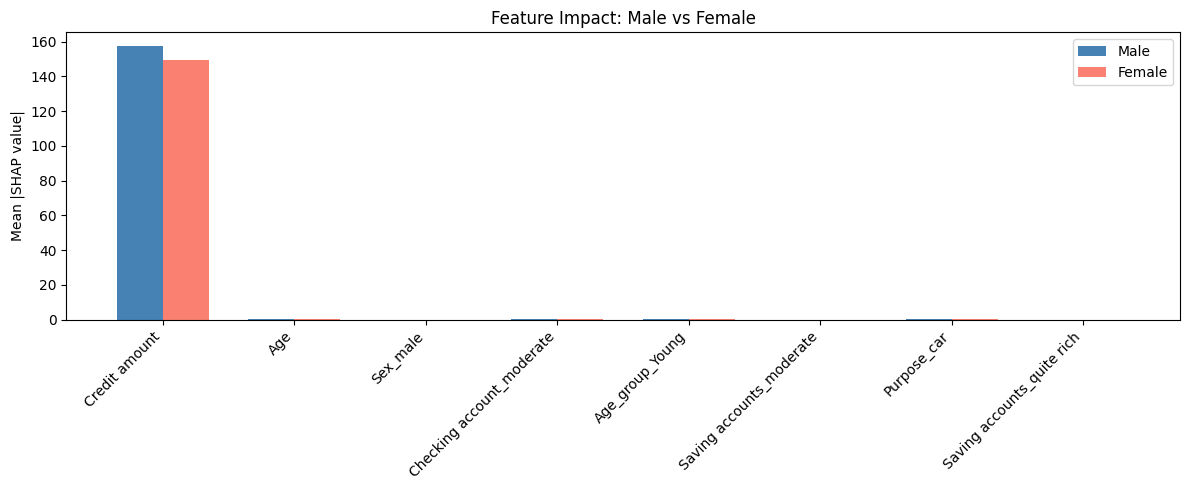

In [18]:
top_features = shap_comparison.head(8)

x = range(len(top_features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], top_features["Male_SHAP"],   width, label="Male",   color="steelblue")
ax.bar([i + width/2 for i in x], top_features["Female_SHAP"], width, label="Female", color="salmon")

ax.set_xticks(list(x))
ax.set_xticklabels(top_features["Feature"], rotation=45, ha="right")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Feature Impact: Male vs Female")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/shap_gender_gap.png")
plt.show()


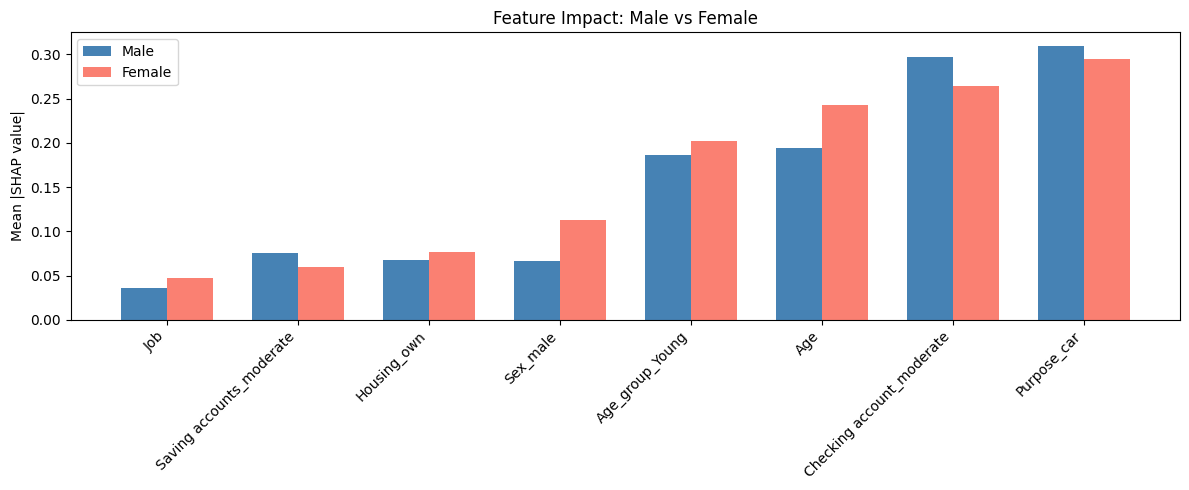

Saved.


In [19]:
import numpy as np
import matplotlib.pyplot as plt

shap_vals = shap_values.values
feature_names = X_test.columns.tolist()

# Exclude dominating and leakage columns
exclude = ["Risk_good", "Credit amount"]
keep_idx = [i for i, f in enumerate(feature_names) if f not in exclude]

filtered_vals = shap_vals[:, keep_idx]
filtered_names = [feature_names[i] for i in keep_idx]

# Split by gender
sex_arr = sex_test.values
male_idx = sex_arr == "male"
female_idx = sex_arr == "female"

mean_male   = np.abs(filtered_vals[male_idx]).mean(axis=0)
mean_female = np.abs(filtered_vals[female_idx]).mean(axis=0)

# Top 8 by overall importance
overall = (mean_male + mean_female) / 2
top_idx = np.argsort(overall)[-8:]
top_names  = [filtered_names[i] for i in top_idx]
top_male   = mean_male[top_idx]
top_female = mean_female[top_idx]

# Plot
x = np.arange(len(top_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, top_male,   width, label="Male",   color="steelblue")
ax.bar(x + width/2, top_female, width, label="Female", color="salmon")

ax.set_xticks(x)
ax.set_xticklabels(top_names, rotation=45, ha="right")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Feature Impact: Male vs Female")
ax.legend()

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/shap_gender_comparison.png", dpi=150)
plt.show()
print("Saved.")